# AIoT Project — Time-Series (windowed raw signal) solution

Human Activity Recognition on **PAMAP2**, ML solution **#1**: the classifiers
are fed the *segmented, windowed raw signal* (flattened window vectors).

Every input is fetched from **MongoDB** (populated by
`aiot_dataset_creation_sample.ipynb`) — the raw `.dat` files are never read here.

**Scope:** `Protocol` split, 12 activities, 9 subjects. We start with the
**hand/wrist** IMU (AccGyr) and then compare the **chest** and **ankle** IMUs.

In [1]:
import os

# basic data engineering
import pandas as pd
import numpy as np
import scipy

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# db
import pymongo

# configs & other
import yaml
from time import time

# utils processing
from utils import sliding_window_pd
from utils import apply_filter
from utils import filter_instances
from utils import flatten_instances_df
from utils import load_segments
from utils import window_segments
from utils import filter_windows
from utils import load_combo
from utils import run_combo_ts
from utils import evaluate

# utils visualization
from utils_visual import plot_np_instance

%load_ext autoreload
%autoreload 2

IMG_DIR = "img"
os.makedirs(IMG_DIR, exist_ok=True)
time_start = time()

## Load configuration

In [2]:
config_path = os.path.join(os.getcwd(), "config.yml")
with open(config_path) as file:
    config = yaml.load(file, Loader=yaml.FullLoader)

SW = config["sliding_window"]      # ws, overlap, w_type
FILT = config["filter"]            # order, wn, type
SPLIT = config["split"]            # train_subjects, test_subjects
print("window size:", SW["ws"], "overlap:", SW["overlap"])
print("filter:", FILT)
print("train subjects:", SPLIT["train_subjects"])
print("test  subjects:", SPLIT["test_subjects"])

window size: 256 overlap: 128
filter: {'order': 4, 'wn': 0.2, 'type': 'lowpass'}
train subjects: ['101', '102', '103', '104', '105', '107']
test  subjects: ['106', '108', '109']


In [3]:
client = pymongo.MongoClient(config["client"])
db = client[config["db"]]
coll = db[config["col"]]
coll.count_documents({})

324

In [4]:
found_labels = coll.distinct("activity_label")
print("Activities in DB:", found_labels)

Activities in DB: ['ascending_stairs', 'cycling', 'descending_stairs', 'ironing', 'lying', 'nordic_walking', 'rope_jumping', 'running', 'sitting', 'standing', 'vacuum_cleaning', 'walking']


## Load data

Fetch the documents for the sensor configuration under evaluation. We start
with the **hand/wrist IMU, AccGyr** configuration (`Protocol` split). Each
document is one contiguous activity segment; we turn it into a 6-channel
DataFrame and keep the `activity_label` and `subject` alongside it (the
`subject` is needed for the subject-disjoint split later).

In [5]:
segments = load_segments(coll, "hand")
print("hand segments:", len(segments))
print("channels:", list(segments[0]["df"].columns))
segments[0]["df"].head()

hand segments: 108
channels: ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']


,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z
0,2.21530,8.27915,5.58753,-0.004750,0.037579,-0.011145
1,2.29196,7.67288,5.74467,-0.171710,0.025479,-0.009538
2,2.29090,7.14240,5.82342,-0.238241,0.011214,0.000831
3,2.21800,7.14365,5.89930,-0.192912,0.019053,0.013374
4,2.30106,7.25857,6.09259,-0.069961,-0.018328,0.004582


## Explore the nature of the data

Three exploratory views, as suggested in the project skeleton:
1. total recording time per activity,
2. one raw signal segment per activity (signal shape per class),
3. the number of segments per `(subject, activity)` — this exposes the class
   imbalance (e.g. `subject109` only performed rope jumping in the Protocol).

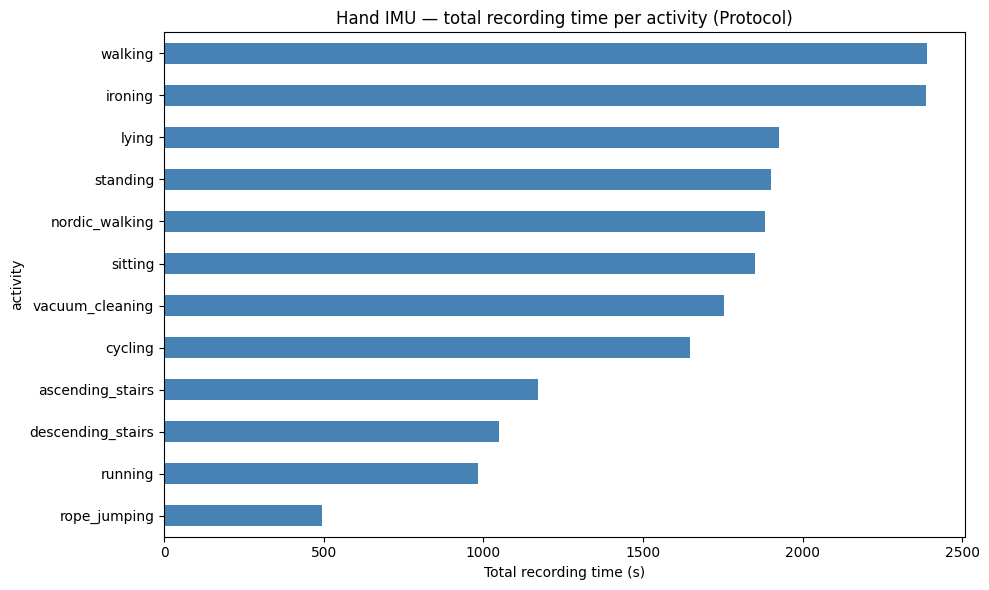

In [6]:
# (1) Total recording time per activity (seconds)
rows = [(s["label"], len(s["df"]) / 100.0) for s in segments]
time_df = pd.DataFrame(rows, columns=["activity", "seconds"])
time_per_act = time_df.groupby("activity")["seconds"].sum().sort_values()

plt.figure(figsize=(10, 6))
time_per_act.plot(kind="barh", color="steelblue")
plt.xlabel("Total recording time (s)")
plt.title("Hand IMU — total recording time per activity (Protocol)")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "ts_recording_time_per_activity.png"), dpi=120)
plt.show()

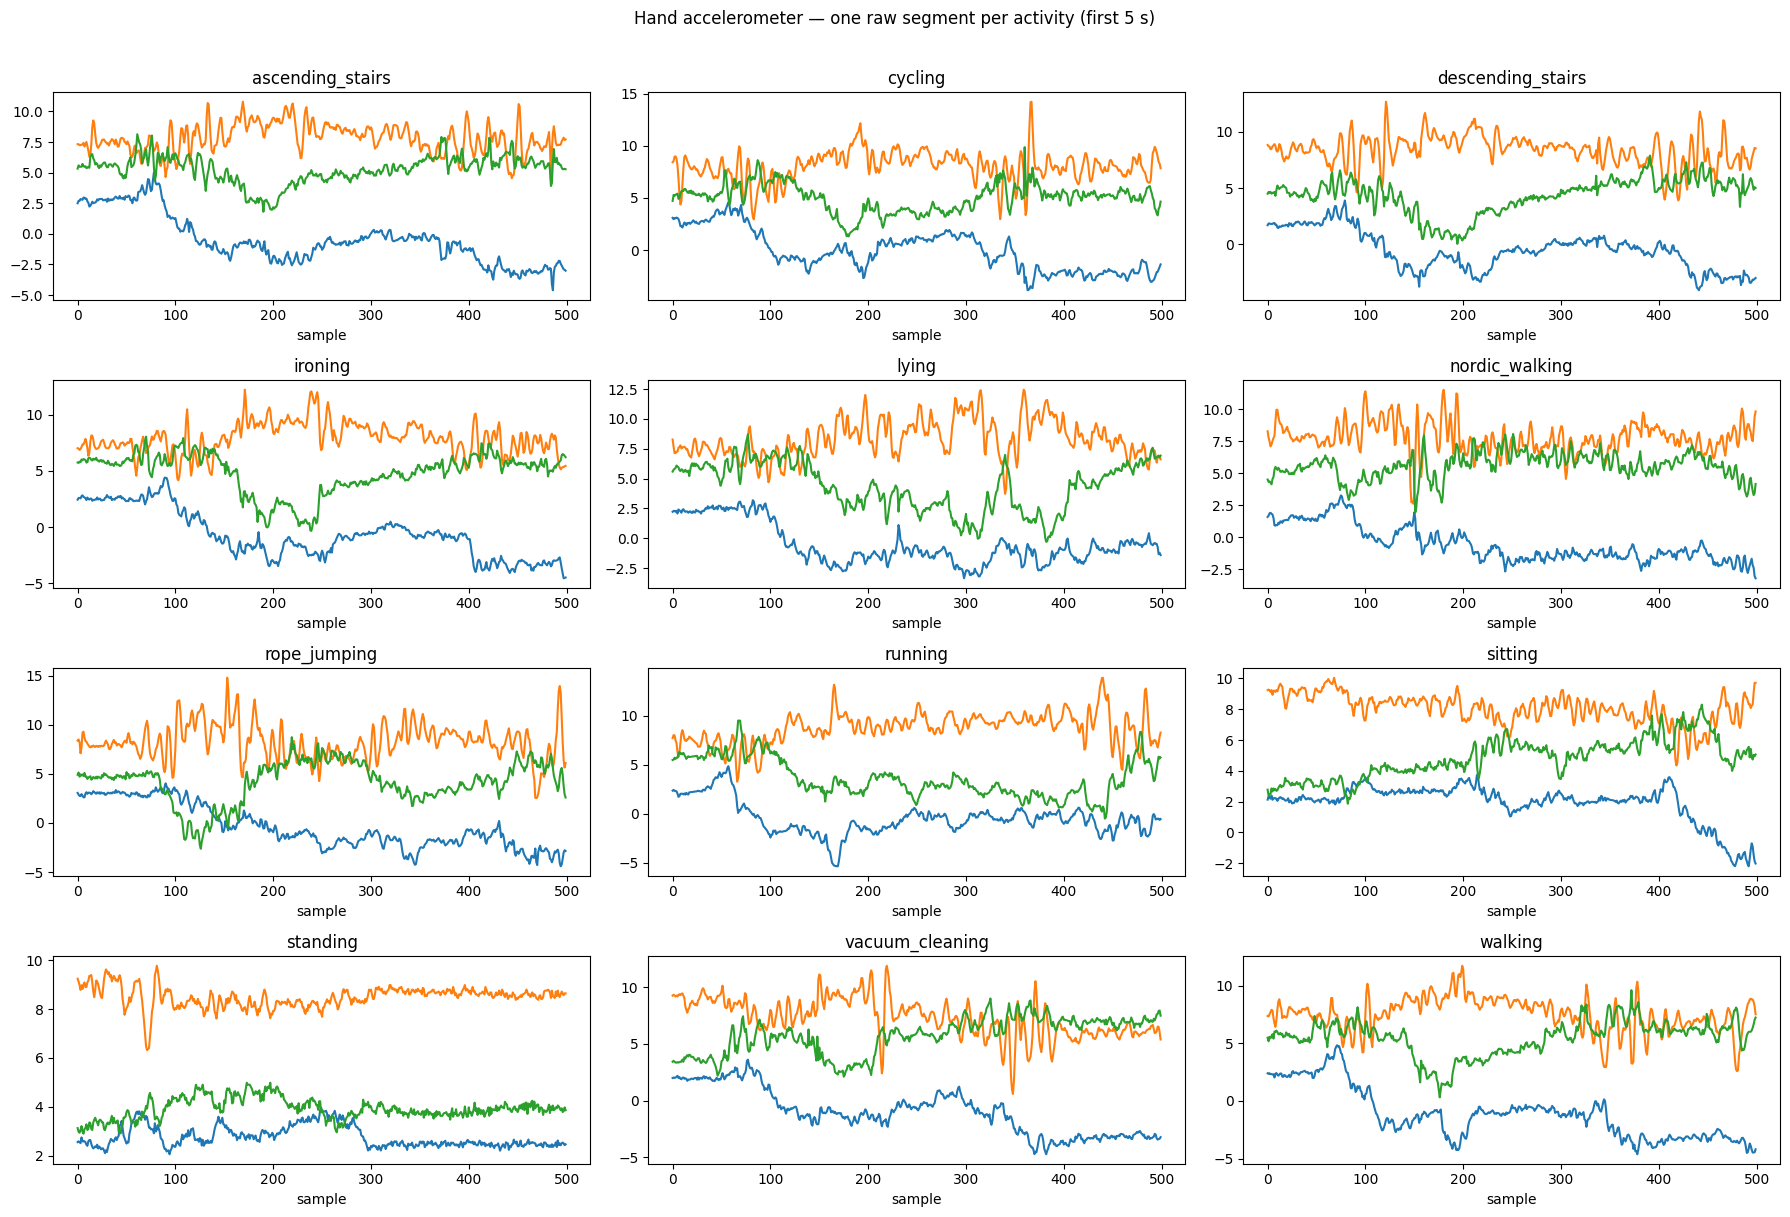

In [7]:
# (2) One representative raw segment per activity (first 500 samples)
labels_sorted = sorted({s["label"] for s in segments})
fig, axes = plt.subplots(4, 3, figsize=(18, 12))
for ax, lab in zip(axes.ravel(), labels_sorted):
    seg = next(s for s in segments if s["label"] == lab)
    seg["df"][["acc_x", "acc_y", "acc_z"]].iloc[:500].plot(ax=ax, legend=False)
    ax.set_title(lab)
    ax.set_xlabel("sample")
fig.suptitle("Hand accelerometer — one raw segment per activity (first 5 s)", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "ts_signal_per_activity.png"), dpi=120)
plt.show()

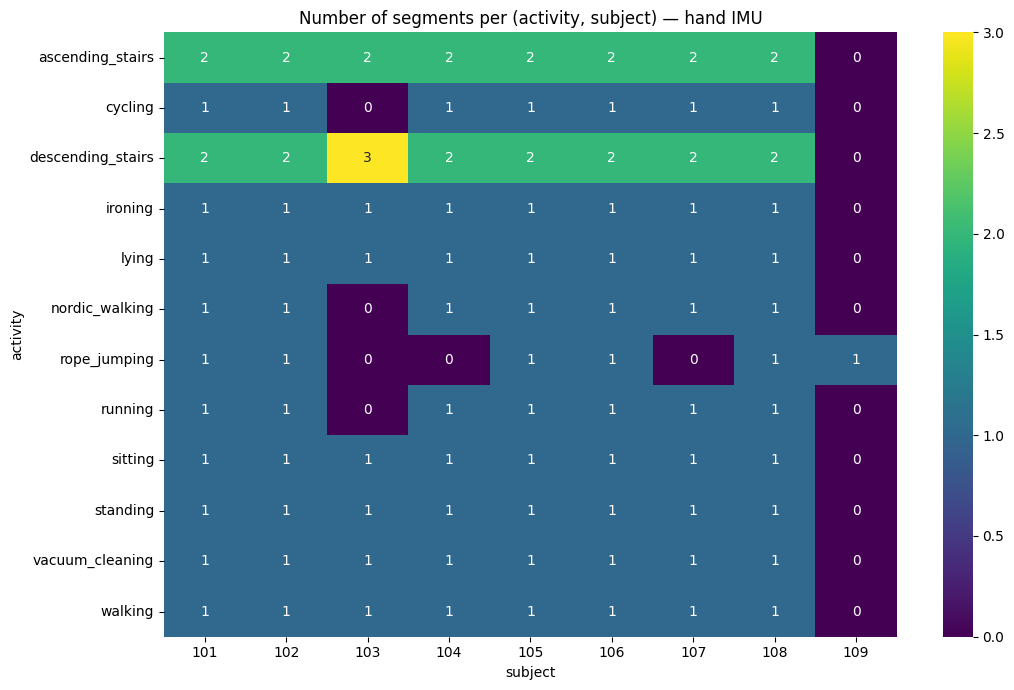

In [8]:
# (3) Segment count per (subject, activity) — class/subject imbalance
counts = pd.DataFrame([(s["subject"], s["label"]) for s in segments],
                      columns=["subject", "activity"])
pivot = counts.pivot_table(index="activity", columns="subject",
                           aggfunc=len, fill_value=0)
plt.figure(figsize=(11, 7))
sns.heatmap(pivot, annot=True, fmt="d", cmap="viridis")
plt.title("Number of segments per (activity, subject) — hand IMU")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "ts_segments_per_subject_activity.png"), dpi=120)
plt.show()

## Data Processing

* **Sliding window**: each segment is split into fixed windows of
  `ws` samples with `ws - overlap` hop (50% overlap), using
  `sliding_window_pd` from `utils.py`. The window's `activity_label` and
  `subject` are carried along.
* **Low-pass Butterworth filter** applied to every window (`apply_filter`).
* Confirm that **no NaN** survive and look at the filter effect on one window.

In [9]:
windows, y, subjects = window_segments(segments, SW["ws"], SW["overlap"], SW["w_type"])
print("total windows:", len(windows), "| window shape:", windows[0].shape)

total windows: 15023 | window shape: (256, 6)


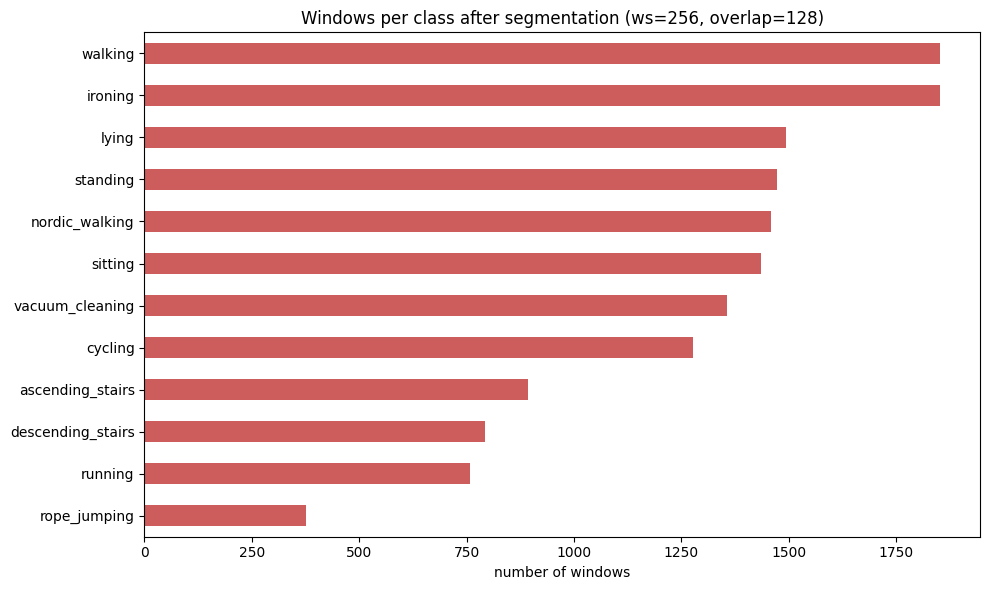

imbalance ratio (max/min): 4.9


In [10]:
# Window count per class after segmentation
wc = pd.Series(y).value_counts().sort_values()
plt.figure(figsize=(10, 6))
wc.plot(kind="barh", color="indianred")
plt.xlabel("number of windows")
plt.title(f"Windows per class after segmentation (ws={SW['ws']}, overlap={SW['overlap']})")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "ts_windows_per_class.png"), dpi=120)
plt.show()
print("imbalance ratio (max/min):", round(wc.max() / wc.min(), 1))

In [11]:
t = time()
windows_f = filter_windows(windows, FILT["order"], FILT["wn"], FILT["type"])
print(f"filtered {len(windows_f)} windows in {time() - t:.1f}s")
nan_total = sum(int(w.isna().sum().sum()) for w in windows_f)
print("NaN values remaining across all windows:", nan_total)

filtered 15023 windows in 61.5s


NaN values remaining across all windows: 0


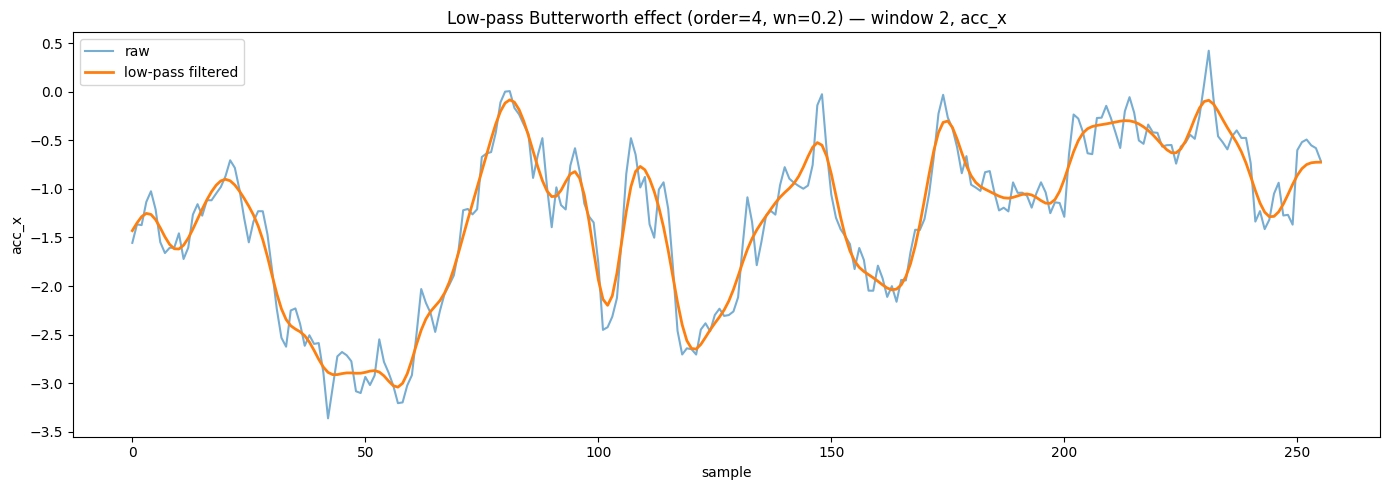

In [12]:
# Visualize the low-pass filter effect on one window (acc_x)
i = config.get("x_number", 2)
plt.figure(figsize=(14, 5))
plt.plot(windows[i]["acc_x"].to_numpy(), label="raw", alpha=0.6)
plt.plot(windows_f[i]["acc_x"].to_numpy(), label="low-pass filtered", linewidth=2)
plt.title(f"Low-pass Butterworth effect (order={FILT['order']}, wn={FILT['wn']}) — window {i}, acc_x")
plt.xlabel("sample"); plt.ylabel("acc_x"); plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "ts_filter_effect.png"), dpi=120)
plt.show()

### Input vector — flatten the windows

Each filtered window (`ws` samples x 6 channels) is flattened into a single
feature row. This is the *time-series* input vector fed to the classifiers.

In [13]:
X = flatten_instances_df(windows_f).to_numpy()
print("flattened input matrix:", X.shape, "(windows x ws*channels)")

flattened input matrix: (15023, 1536) (windows x ws*channels)


## Train/Test split

The split is **by subject**: 6 subjects for training, 3 for testing, with no
overlap, so the evaluation reflects generalization to unseen users. We do
**not** use a random shuffled split (that would leak windows of the same
subject into both sets).

In [14]:
TRAIN_SUBJECTS = SPLIT["train_subjects"]
TEST_SUBJECTS = SPLIT["test_subjects"]
assert set(TRAIN_SUBJECTS).isdisjoint(TEST_SUBJECTS)
print("train:", TRAIN_SUBJECTS, "| test:", TEST_SUBJECTS)

train: ['101', '102', '103', '104', '105', '107'] | test: ['106', '108', '109']


In [15]:
train_mask = np.isin(subjects, TRAIN_SUBJECTS)
test_mask = np.isin(subjects, TEST_SUBJECTS)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
print("train windows:", X_train.shape[0], "| test windows:", X_test.shape[0])

train windows: 11014 | test windows: 4009


## Scaling

Standardize the features. The scaler is fit **only on the training subjects**
and then applied to the test subjects.

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)
print("scaled. train mean ~0:", round(float(X_train_s.mean()), 4))

scaled. train mean ~0: -0.0


## Classifier — Statistical Learning

### Apply simple classifier

Two supervised models on the raw windowed input: a **Random Forest** (robust to
high-dimensional flattened windows) and an **SVM** (RBF kernel).

In [17]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

rf_cfg = config["classifier"]["RandomForest"]
svc_cfg = config["classifier"]["SVC"]

t = time()
rf = RandomForestClassifier(n_estimators=rf_cfg["n_estimators"],
                            max_depth=rf_cfg["max_depth"],
                            random_state=42, n_jobs=-1).fit(X_train_s, y_train)
print(f"RF trained in {time() - t:.1f}s")

t = time()
svm = SVC(C=svc_cfg["C"], kernel=svc_cfg["kernel"],
          gamma=svc_cfg["gamma"]).fit(X_train_s, y_train)
print(f"SVM trained in {time() - t:.1f}s")

RF trained in 14.0s


SVM trained in 44.5s


### Evaluate simple classifier

=== Time-series — Random Forest (hand) ===
accuracy: 0.642 | macro-F1: 0.612

                   precision    recall  f1-score   support

 ascending_stairs       0.85      0.46      0.60       190
          cycling       0.54      0.69      0.61       357
descending_stairs       0.25      0.24      0.24       157
          ironing       0.59      0.60      0.60       549
            lying       0.74      0.93      0.82       368
   nordic_walking       0.95      0.47      0.63       431
     rope_jumping       1.00      0.32      0.48       116
          running       1.00      0.88      0.93       305
          sitting       0.43      0.66      0.52       357
         standing       0.81      0.40      0.53       384
  vacuum_cleaning       0.46      0.62      0.53       351
          walking       0.78      0.94      0.85       444

         accuracy                           0.64      4009
        macro avg       0.70      0.60      0.61      4009
     weighted avg       0.70      0

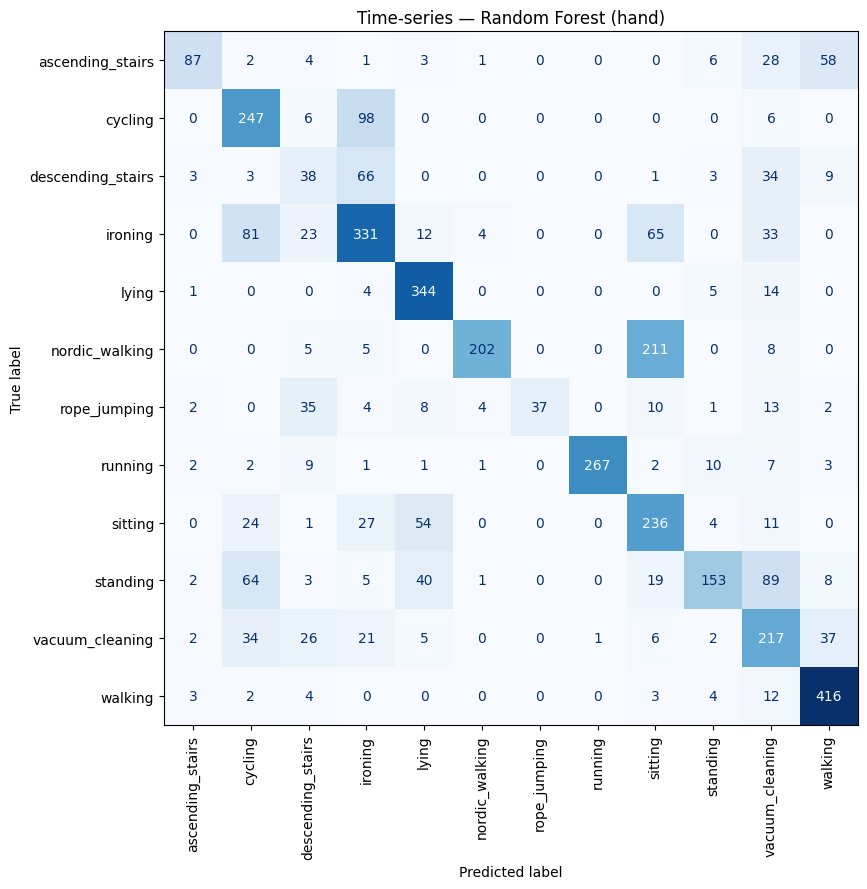

=== Time-series — SVM RBF (hand) ===
accuracy: 0.572 | macro-F1: 0.548

                   precision    recall  f1-score   support

 ascending_stairs       0.63      0.65      0.64       190
          cycling       0.48      0.76      0.59       357
descending_stairs       0.59      0.61      0.60       157
          ironing       0.56      0.29      0.38       549
            lying       0.75      0.94      0.83       368
   nordic_walking       0.99      0.46      0.63       431
     rope_jumping       0.24      0.87      0.38       116
          running       0.00      0.00      0.00       305
          sitting       0.70      0.64      0.67       357
         standing       0.76      0.42      0.54       384
  vacuum_cleaning       0.33      0.78      0.46       351
          walking       0.96      0.75      0.85       444

         accuracy                           0.57      4009
        macro avg       0.58      0.60      0.55      4009
     weighted avg       0.63      0.57   

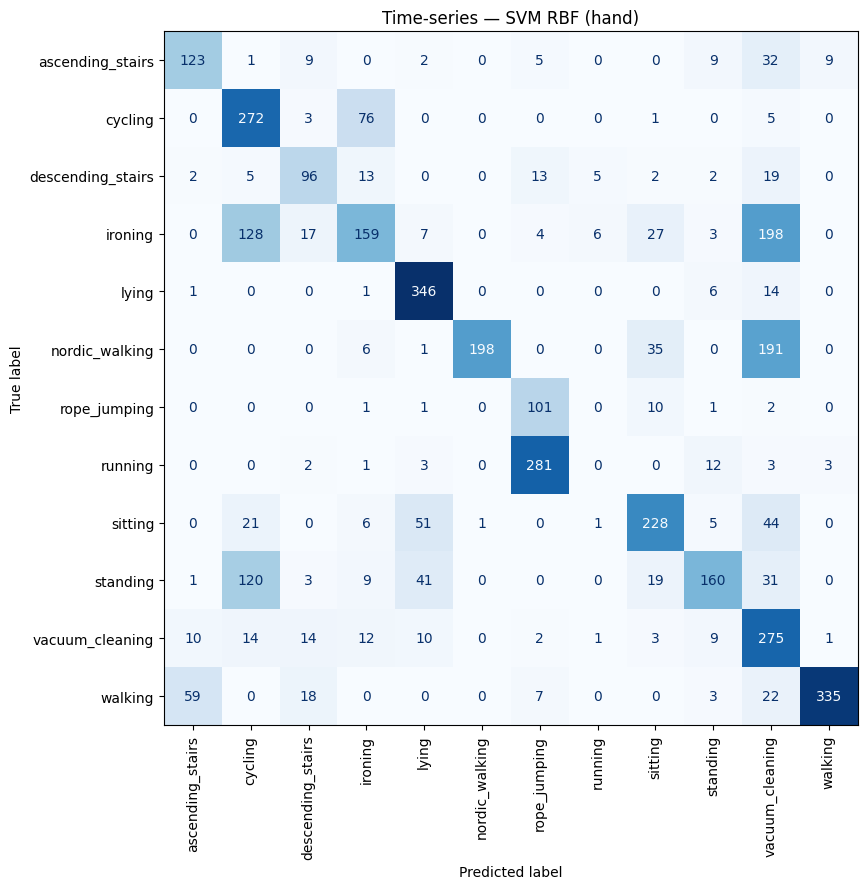

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, accuracy_score, f1_score


evaluate(rf, X_test_s, y_test, "Time-series — Random Forest (hand)", "ts_cm_rf.png")
evaluate(svm, X_test_s, y_test, "Time-series — SVM RBF (hand)", "ts_cm_svm.png");

### Apply optimization with Grid Search and/or Cross-validation

The flattened raw windows are very high-dimensional, which makes an exhaustive
SVM grid prohibitively slow here, so we tune the **Random Forest** (the better
base model on this representation) with a compact grid. The exhaustive **SVM**
`GridSearchCV` using the `config.yml` `param_grid` is performed in the
*feature-engineering* notebook, where the input dimensionality is small.

In [19]:
from sklearn.model_selection import GridSearchCV

rf_grid = {"n_estimators": [100, 200, 300], "max_depth": [None, 20, 40]}
gs = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                  rf_grid, cv=3, verbose=1, n_jobs=-1)
t = time()
gs.fit(X_train_s, y_train)
print(f"\ngrid search done in {time() - t:.1f}s")
print("best params:", gs.best_params_)
print("best CV score:", round(gs.best_score_, 3))

Fitting 3 folds for each of 9 candidates, totalling 27 fits



grid search done in 239.8s
best params: {'max_depth': None, 'n_estimators': 300}
best CV score: 0.711


### Evaluate optimized classifier

=== Time-series — tuned Random Forest (hand) ===
accuracy: 0.644 | macro-F1: 0.615

                   precision    recall  f1-score   support

 ascending_stairs       0.88      0.49      0.63       190
          cycling       0.55      0.70      0.62       357
descending_stairs       0.25      0.24      0.24       157
          ironing       0.58      0.61      0.59       549
            lying       0.74      0.93      0.82       368
   nordic_walking       0.94      0.47      0.62       431
     rope_jumping       1.00      0.32      0.48       116
          running       1.00      0.89      0.94       305
          sitting       0.42      0.66      0.51       357
         standing       0.82      0.40      0.53       384
  vacuum_cleaning       0.45      0.61      0.52       351
          walking       0.79      0.94      0.86       444

         accuracy                           0.64      4009
        macro avg       0.70      0.60      0.61      4009
     weighted avg       0.70 

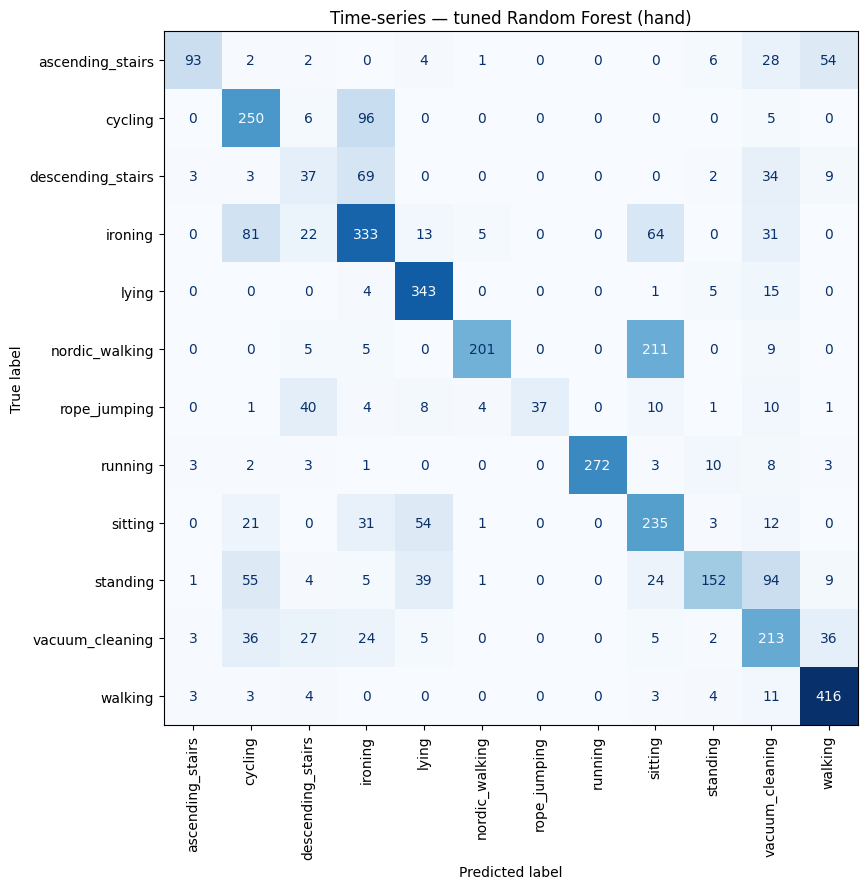

In [20]:
evaluate(gs.best_estimator_, X_test_s, y_test,
         "Time-series — tuned Random Forest (hand)", "ts_cm_tuned.png");

## Sensor configuration comparison

The Sensor Selection Strategy in the assignment asks us to *expand* the
wrist-only configuration incrementally and report the per-configuration
metrics. We therefore evaluate four cumulative configurations on the same
pipeline (window → filter → flatten → subject-disjoint split → scale → Random
Forest):

- `hand` (baseline, 6 channels),
- `hand + chest` (12 channels),
- `hand + ankle` (12 channels),
- `hand + chest + ankle` (18 channels).

The channels of the additional IMUs are concatenated to the wrist channels per
segment (matched across IMU locations by insertion order, since the ingestion
notebook inserts the hand/chest/ankle triplet of every segment together).

In [21]:
combos = [["hand"], ["hand", "chest"], ["hand", "ankle"], ["hand", "chest", "ankle"]]
results = [run_combo_ts(coll, c, SW, FILT, TRAIN_SUBJECTS, TEST_SUBJECTS, rf_cfg) for c in combos]
res_df = pd.DataFrame(results).set_index("combo")
print(res_df.round(3))

                  n_channels  accuracy  macro_f1
combo                                           
hand                       6     0.642     0.612
hand+chest                12     0.790     0.756
hand+ankle                12     0.643     0.608
hand+chest+ankle          18     0.784     0.750


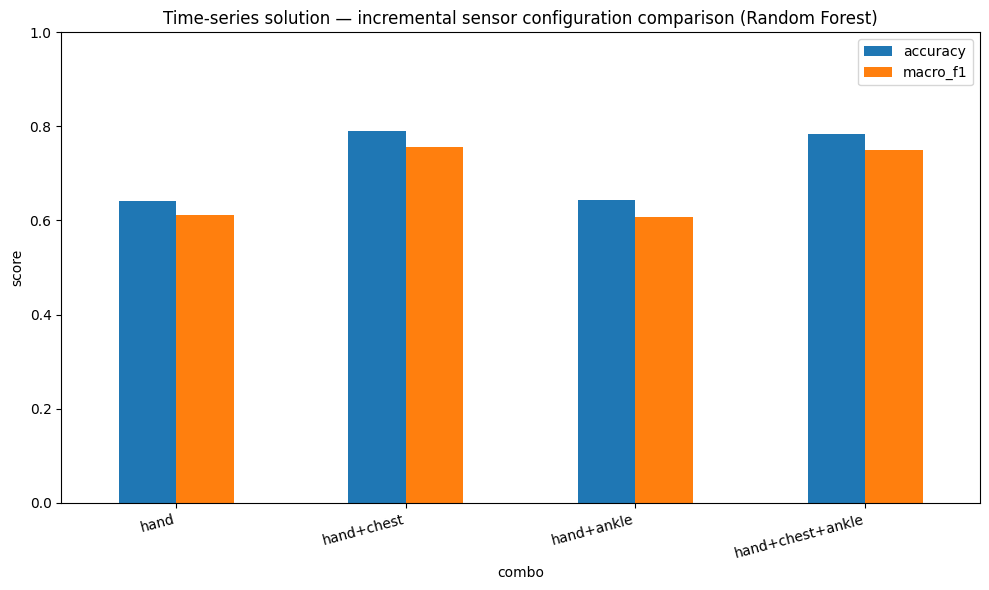

In [22]:
ax = res_df[["accuracy", "macro_f1"]].plot(kind="bar", figsize=(10, 6))
ax.set_ylabel("score"); ax.set_ylim(0, 1)
ax.set_title("Time-series solution — incremental sensor configuration comparison (Random Forest)")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "ts_sensor_comparison.png"), dpi=120)
plt.show()

In [23]:
print(f"Notebook total runtime: {time() - time_start:.1f}s")

Notebook total runtime: 1113.3s
